In [1]:
import sys
import os

# Move one directory up (to project root)
project_root = os.path.abspath("..")
sys.path.append(project_root)

print("Added to PYTHONPATH:", project_root)

Added to PYTHONPATH: /vols/cms/mm1221/geant4sim/scripts/validation_new


In [61]:
import pandas as pd

# --- File paths ---
contrastive_path = "../out_HD.csv"
oc_path          = "../out_oc.csv"

# --- Load CSV files ---
df_contrastive = pd.read_csv(contrastive_path)
df_oc          = pd.read_csv(oc_path)



In [62]:
from src.metrics.calculations import calc_ratio

print("=== Number Ratio (Reco / CP) ===\n")

ratio_contrastive = calc_ratio(df_contrastive)
ratio_oc          = calc_ratio(df_oc)

print(f"Contrastive ratio : {ratio_contrastive:.3f}")
print(f"Object Condensation ratio : {ratio_oc:.3f}")

=== Number Ratio (Reco / CP) ===

Contrastive ratio : 0.969
Object Condensation ratio : 0.891


In [68]:
import numpy as np
import matplotlib.pyplot as plt

from src.metrics.calculations import calc_purity, calc_efficiency

# 1) Efficiency binning

all_cp = np.concatenate([
    df_contrastive["PrimaryEnergy"].values,
    df_oc["PrimaryEnergy"].values,
])

n_bins = 10
cp_bins = np.linspace(all_cp.min(), all_cp.max(), n_bins + 1)
cp_bin_centers = 0.5 * (cp_bins[:-1] + cp_bins[1:])

eff_contrastive = []
eff_oc = []

for i in range(n_bins):
    low, high = cp_bins[i], cp_bins[i + 1]

    df_c_bin = df_contrastive[(df_contrastive["PrimaryEnergy"] >= low) &
                               (df_contrastive["PrimaryEnergy"] < high)]
    df_oc_bin = df_oc[(df_oc["PrimaryEnergy"] >= low) &
                      (df_oc["PrimaryEnergy"] < high)]

    eff_contrastive.append(calc_efficiency(df_c_bin, threshold=0.5) if len(df_c_bin) else np.nan)
    eff_oc.append(calc_efficiency(df_oc_bin, threshold=0.5) if len(df_oc_bin) else np.nan)


# 2) Purity binning restricted to 10–100 GeV reco_energy

LOW = 100    # 10 GeV in MeV
HIGH = 3000  # 100 GeV in MeV

# mask to only use events in this physical range
df_c_restricted = df_contrastive[(df_contrastive["reco_energy"] >= LOW) &
                                 (df_contrastive["reco_energy"] <= HIGH)]
df_oc_restricted = df_oc[(df_oc["reco_energy"] >= LOW) &
                         (df_oc["reco_energy"] <= HIGH)]

# choose bins **within this restricted range only**
reco_bins = np.linspace(LOW, HIGH, n_bins + 1)
reco_bin_centers = 0.5 * (reco_bins[:-1] + reco_bins[1:])

purity_contrastive = []
purity_oc = []

for i in range(n_bins):
    low, high = reco_bins[i], reco_bins[i + 1]

    df_c_bin = df_c_restricted[(df_c_restricted["reco_energy"] >= low) &
                               (df_c_restricted["reco_energy"] < high)]
    df_oc_bin = df_oc_restricted[(df_oc_restricted["reco_energy"] >= low) &
                                 (df_oc_restricted["reco_energy"] < high)]

    purity_contrastive.append(calc_purity(df_c_bin, threshold=0.2) if len(df_c_bin) else np.nan)
    purity_oc.append(calc_purity(df_oc_bin, threshold=0.2) if len(df_oc_bin) else np.nan)

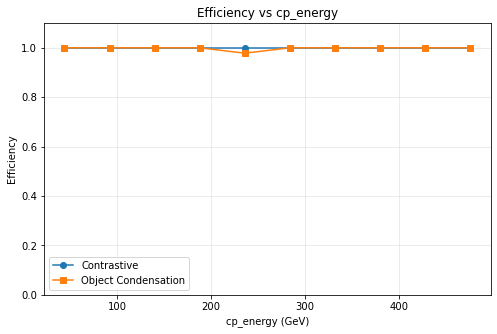

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(cp_bin_centers/1000, eff_contrastive, "o-", label="Contrastive")
plt.plot(cp_bin_centers/1000, eff_oc, "s-", label="Object Condensation")

plt.xlabel("cp_energy (GeV)")
plt.ylabel("Efficiency")
plt.title("Efficiency vs cp_energy")
plt.ylim(0,1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

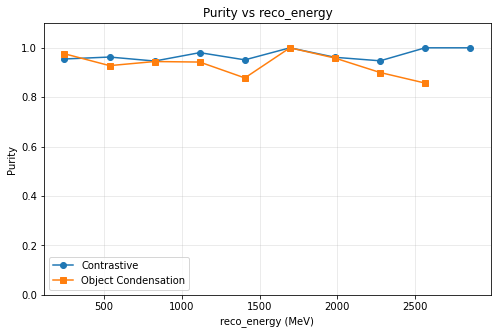

In [70]:
plt.figure(figsize=(8, 5))

plt.plot(reco_bin_centers, purity_contrastive, "o-", label="Contrastive")
plt.plot(reco_bin_centers, purity_oc, "s-", label="Object Condensation")

plt.xlabel("reco_energy (MeV)")
plt.ylabel("Purity")
plt.title("Purity vs reco_energy")
plt.ylim(0,1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

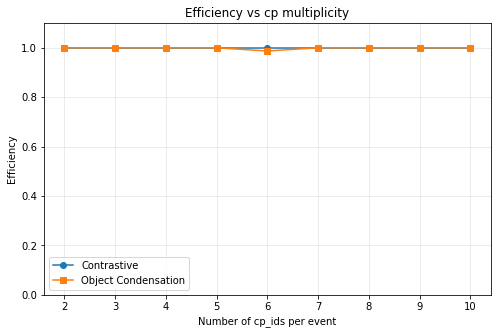

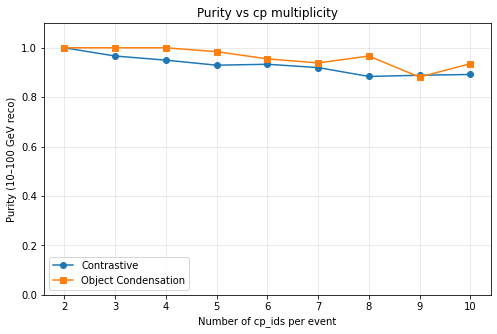

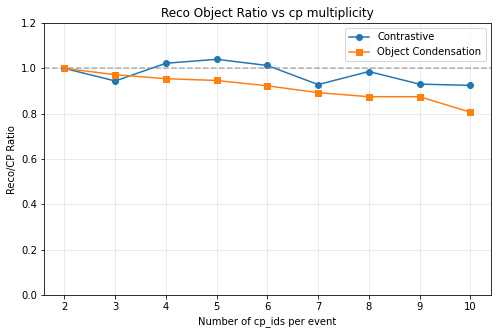

In [66]:
import numpy as np
import matplotlib.pyplot as plt

from src.metrics.calculations import calc_purity, calc_efficiency, calc_ratio

# -------------------------------------------------
# 0) Compute cp multiplicity per event
# -------------------------------------------------

cp_per_event = (
    df_contrastive[["event_id", "cp_id"]]
    .drop_duplicates()
    .groupby("event_id")["cp_id"]
    .nunique()
)

multiplicities = np.sort(cp_per_event.unique())

# -------------------------------------------------
# 1) Efficiency vs multiplicity
# -------------------------------------------------

eff_contrastive = []
eff_oc = []

for m in multiplicities:
    event_ids_m = cp_per_event.index[cp_per_event == m]

    df_c_m = df_contrastive[df_contrastive["event_id"].isin(event_ids_m)]
    df_oc_m = df_oc[df_oc["event_id"].isin(event_ids_m)]

    eff_contrastive.append(calc_efficiency(df_c_m, threshold=0.5) if len(df_c_m) else np.nan)
    eff_oc.append(calc_efficiency(df_oc_m, threshold=0.5) if len(df_oc_m) else np.nan)

# -------------------------------------------------
# 2) Purity vs multiplicity (10–100 GeV reco)
# -------------------------------------------------

LOW = 0
HIGH = 2000

df_c_res = df_contrastive[(df_contrastive["reco_energy"] >= LOW) &
                          (df_contrastive["reco_energy"] <= HIGH)]
df_oc_res = df_oc[(df_oc["reco_energy"] >= LOW) &
                  (df_oc["reco_energy"] <= HIGH)]

purity_contrastive = []
purity_oc = []

for m in multiplicities:
    event_ids_m = cp_per_event.index[cp_per_event == m]

    df_c_m_r = df_c_res[df_c_res["event_id"].isin(event_ids_m)]
    df_oc_m_r = df_oc_res[df_oc_res["event_id"].isin(event_ids_m)]

    purity_contrastive.append(calc_purity(df_c_m_r, threshold=0.2) if len(df_c_m_r) else np.nan)
    purity_oc.append(calc_purity(df_oc_m_r, threshold=0.2) if len(df_oc_m_r) else np.nan)

# -------------------------------------------------
# 3) Number Ratio vs multiplicity
# -------------------------------------------------

ratio_contrastive = []
ratio_oc = []

for m in multiplicities:
    event_ids_m = cp_per_event.index[cp_per_event == m]

    df_c_m = df_contrastive[df_contrastive["event_id"].isin(event_ids_m)]
    df_oc_m = df_oc[df_oc["event_id"].isin(event_ids_m)]

    ratio_contrastive.append(calc_ratio(df_c_m) if len(df_c_m) else np.nan)
    ratio_oc.append(calc_ratio(df_oc_m) if len(df_oc_m) else np.nan)

# -------------------------------------------------
# 4) Plots
# -------------------------------------------------

# --- Efficiency Plot ---
plt.figure(figsize=(8, 5))
plt.plot(multiplicities, eff_contrastive, "o-", label="Contrastive")
plt.plot(multiplicities, eff_oc, "s-", label="Object Condensation")
plt.xlabel("Number of cp_ids per event")
plt.ylabel("Efficiency")
plt.title("Efficiency vs cp multiplicity")
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- Purity Plot ---
plt.figure(figsize=(8, 5))
plt.plot(multiplicities, purity_contrastive, "o-", label="Contrastive")
plt.plot(multiplicities, purity_oc, "s-", label="Object Condensation")
plt.xlabel("Number of cp_ids per event")
plt.ylabel("Purity (10–100 GeV reco)")
plt.title("Purity vs cp multiplicity")
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- Number Ratio Plot ---
plt.figure(figsize=(8, 5))
plt.plot(multiplicities, ratio_contrastive, "o-", label="Contrastive")
plt.plot(multiplicities, ratio_oc, "s-", label="Object Condensation")
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.6)
plt.xlabel("Number of cp_ids per event")
plt.ylabel("Reco/CP Ratio")
plt.title("Reco Object Ratio vs cp multiplicity")
plt.ylim(0, max(np.nanmax(ratio_contrastive), np.nanmax(ratio_oc), 1.2))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

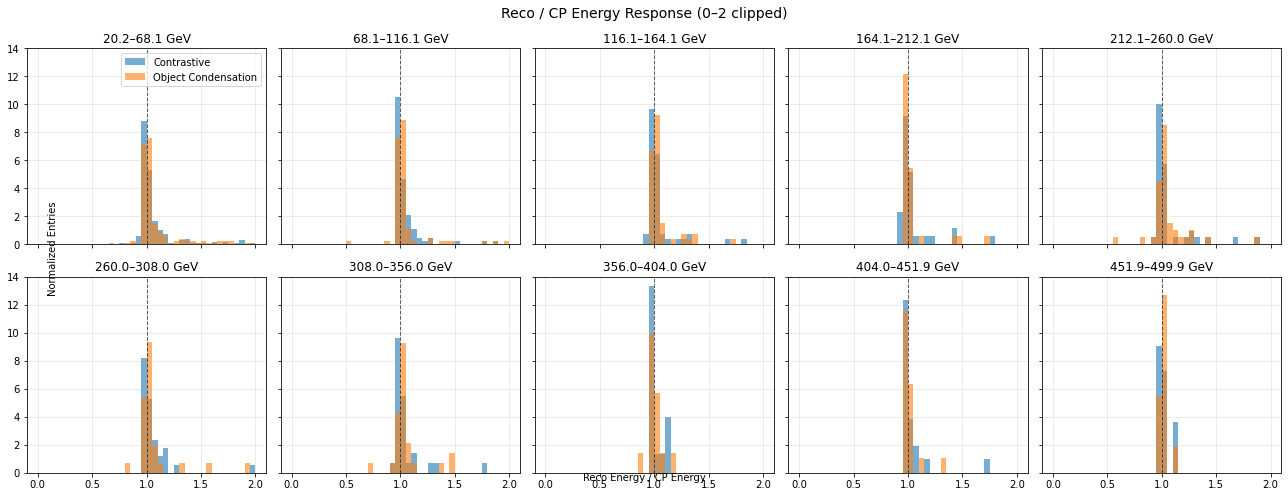

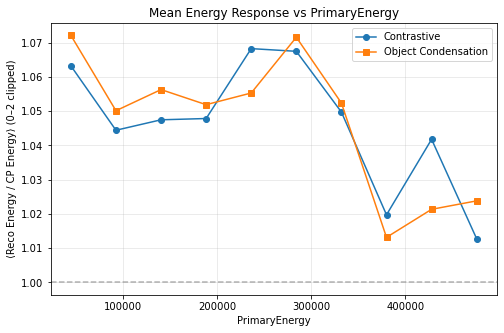

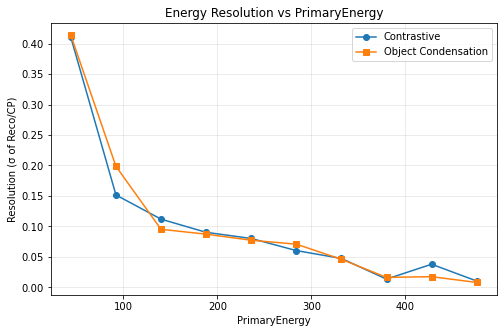

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================
# Energy response vs PrimaryEnergy (Contrastive vs OC)
# Best-matched reco per CP (min RtS), clipped to [0, 2]
# Also computes RESOLUTION = width (std dev) per energy bin
# =================================================

# -------------------------------------------------
# 1) Define PrimaryEnergy bins
# -------------------------------------------------

n_bins = 10

all_cp_energy = np.concatenate([
    df_contrastive["PrimaryEnergy"].values,
    df_oc["PrimaryEnergy"].values,
])

energy_bins = np.linspace(all_cp_energy.min(), all_cp_energy.max(), n_bins + 1)
energy_bin_centers = 0.5 * (energy_bins[:-1] + energy_bins[1:])

# -------------------------------------------------
# 2) Helper: compute response + mean + resolution
# -------------------------------------------------

def response_by_energy_bin(df, energy_bins, rts_col="shared_energy"):
    response_bins = []
    mean_response = []
    resolution = []   # width = std dev of response

    for i in range(len(energy_bins) - 1):
        low, high = energy_bins[i], energy_bins[i + 1]

        df_bin = df[
            (df["PrimaryEnergy"] >= low) &
            (df["PrimaryEnergy"] < high)
        ]

        responses = []

        for _, df_evt in df_bin.groupby("event_id"):
            for _, df_cp in df_evt.groupby("cp_id"):
                best = df_cp.loc[df_cp[rts_col].idxmax()]

                cp_E = best["cp_energy"]
                reco_E = best["reco_energy"]

                if cp_E > 0:
                    ratio = reco_E / cp_E
                    if 0.0 <= ratio <= 2.0:   # clip outliers
                        responses.append(ratio)

        responses = np.array(responses)

        response_bins.append(responses)

        if len(responses):
            mean_response.append(np.mean(responses))
            resolution.append(np.std(responses))   # RMS width
        else:
            mean_response.append(np.nan)
            resolution.append(np.nan)

    return response_bins, np.array(mean_response), np.array(resolution)

# -------------------------------------------------
# 3) Compute for both models
# -------------------------------------------------

resp_c, mean_c, res_c = response_by_energy_bin(df_contrastive, energy_bins)
resp_oc, mean_oc, res_oc = response_by_energy_bin(df_oc, energy_bins)

# -------------------------------------------------
# 4) Overlayed histograms (10 bins → 10 panels)
# -------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.hist(
        resp_c[i],
        bins=40,
        range=(0, 2),
        density=True,
        alpha=0.6,
        label="Contrastive"
    )
    ax.hist(
        resp_oc[i],
        bins=40,
        range=(0, 2),
        density=True,
        alpha=0.6,
        label="Object Condensation"
    )

    ax.axvline(1.0, linestyle="--", linewidth=1, color="black", alpha=0.6)
    ax.set_title(f"{energy_bins[i]/1e3:.1f}–{energy_bins[i+1]/1e3:.1f} GeV")
    ax.grid(alpha=0.3)

axes[0].legend()
fig.suptitle("Reco / CP Energy Response (0–2 clipped)", fontsize=14)
fig.text(0.5, 0.04, "Reco Energy / CP Energy", ha="center")
fig.text(0.04, 0.5, "Normalized Entries", va="center", rotation="vertical")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 5) Mean response vs PrimaryEnergy
# -------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(energy_bin_centers, mean_c, "o-", label="Contrastive")
plt.plot(energy_bin_centers, mean_oc, "s-", label="Object Condensation")
plt.axhline(1.0, linestyle="--", color="gray", alpha=0.6)
plt.xlabel("PrimaryEnergy")
plt.ylabel("⟨Reco Energy / CP Energy⟩ (0–2 clipped)")
plt.title("Mean Energy Response vs PrimaryEnergy")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# -------------------------------------------------
# 6) Resolution (width) vs PrimaryEnergy
# -------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(energy_bin_centers/1000, (res_c*1000*100)/energy_bin_centers, "o-", label="Contrastive")
plt.plot(energy_bin_centers/1000, (res_oc*1000*100)/energy_bin_centers, "s-", label="Object Condensation")
plt.xlabel("PrimaryEnergy")
plt.ylabel("Resolution (σ of Reco/CP)")
plt.title("Energy Resolution vs PrimaryEnergy")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
